In [104]:
import sys
import os

# add src folder to path
sys.path.append(os.path.abspath("../src")) 

from imports import *
from utils import *

In [ ]:
''' 
This notebook performs data collection and analysis on the forex data. 
    
    1. Collect and preprocess financial time series data:
        Retrieve Forex price data using yfinance 
        Compute daily returns and log returns 

    2. Perform Exploratory Data analysis
        Visual Analysis
            Plot of Prices 
            Plot of Returns
            Histgram w theoretical normal
            QQplots 
            ACF and PACF plots

        Quantitative Analysis
            Returns distribution: Jarque-Bera test
            Autocorrelation Significance: Ljung-Box test
            Heteroskedasticity: ARCH LM test
'''

' \nThis notebook performs data collection and analysis on the forex data. \n\n    1. Collect and preprocess financial time series data:\n        Retrieve Forex price data using yfinance \n        Compute daily returns and log returns \n\n    2. Perform Exploratory Data analysis\n        Visual Analysis\n            Histgram w theoretical normal\n            QQplots \n            ACF and PACF plots\n\n        Quantitative Analysis\n            Returns distribution: Jarque-Bera test\n            Autocorrelation Significance: Ljung-Box test\n            Heteroskedasticity: ARCH LM test\n'

In [106]:
# Load FOREX data
tickers = ["SPY", "AMZN"] # not forex data yet 
start, end = "2014-01-01", "2024-06-30" 

data = yf.download(tickers, start=start, end=end, progress=False)
prices = data["Close"].copy()
prices.dropna(inplace=True)

prices.set_index(prices.index, inplace=True)
prices.columns = tickers

# save data to csv
prices.to_csv("../data/prices.csv")

# check data
print(prices.info())
prices.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2640 entries, 2014-01-02 to 2024-06-28
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     2640 non-null   float64
 1   AMZN    2640 non-null   float64
dtypes: float64(2)
memory usage: 61.9 KB
None


,SPY,AMZN
Date,,
2014-01-02,19.898500,148.986053
2014-01-03,19.822001,148.961594
2014-01-06,19.681499,148.529922
2014-01-07,19.901501,149.442200
2014-01-08,20.096001,149.474701


In [107]:
# Daily returns :
returns = prices.pct_change().dropna()*100

# save returns to csv
returns.to_csv("../data/returns.csv")

# check returns
print(returns.info())
returns.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2639 entries, 2014-01-03 to 2024-06-28
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     2639 non-null   float64
 1   AMZN    2639 non-null   float64
dtypes: float64(2)
memory usage: 61.9 KB
None


,SPY,AMZN
Date,,
2014-01-03,-0.384451,-0.016418
2014-01-06,-0.708814,-0.289787
2014-01-07,1.117807,0.614204
2014-01-08,0.977313,0.021748
2014-01-09,-0.226412,0.065415


In [109]:
# Log returns :
log_returns = np.log(prices / prices.shift(1)).dropna()*100

# save log returns to csv
log_returns.to_csv("../data/log_returns.csv")

# check log returns
print(log_returns.info())
log_returns.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2639 entries, 2014-01-03 to 2024-06-28
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     2639 non-null   float64
 1   AMZN    2639 non-null   float64
dtypes: float64(2)
memory usage: 61.9 KB
None


,SPY,AMZN
Date,,
2014-01-03,-0.385192,-0.016419
2014-01-06,-0.711338,-0.290208
2014-01-07,1.111606,0.612326
2014-01-08,0.972568,0.021746
2014-01-09,-0.226669,0.065393


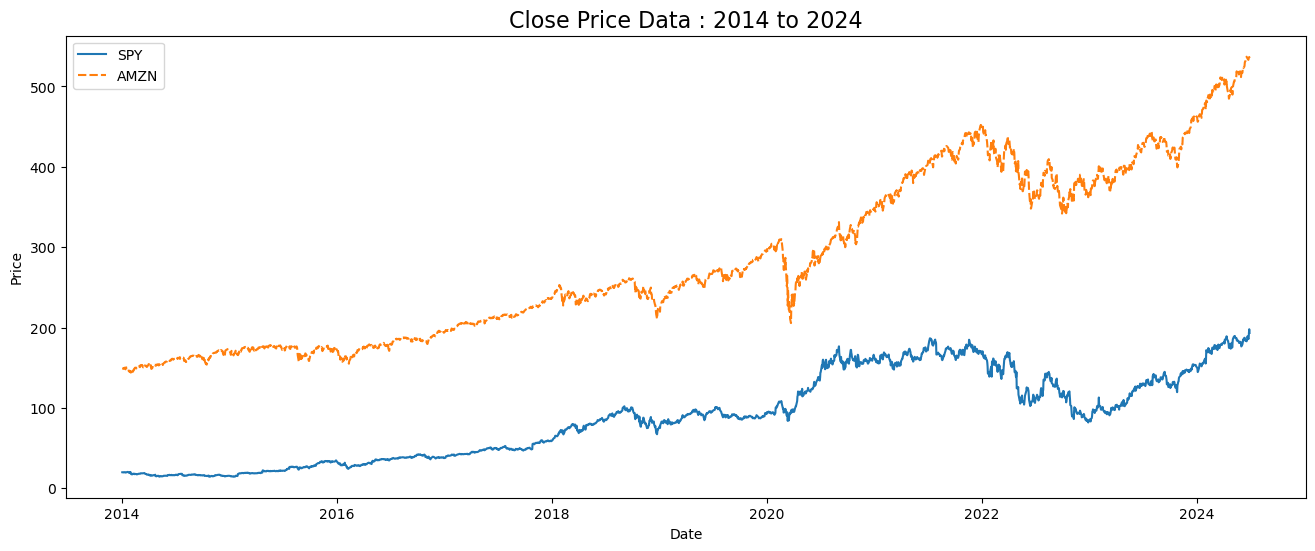

In [110]:
# Plot price data
plt.figure(figsize=(16, 6))

sns.lineplot(data=prices)

title = "Close Price Data"
plt.title(f"{title} : {start[:4]} to {end[:4]}", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

# save plot
plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

plt.show()

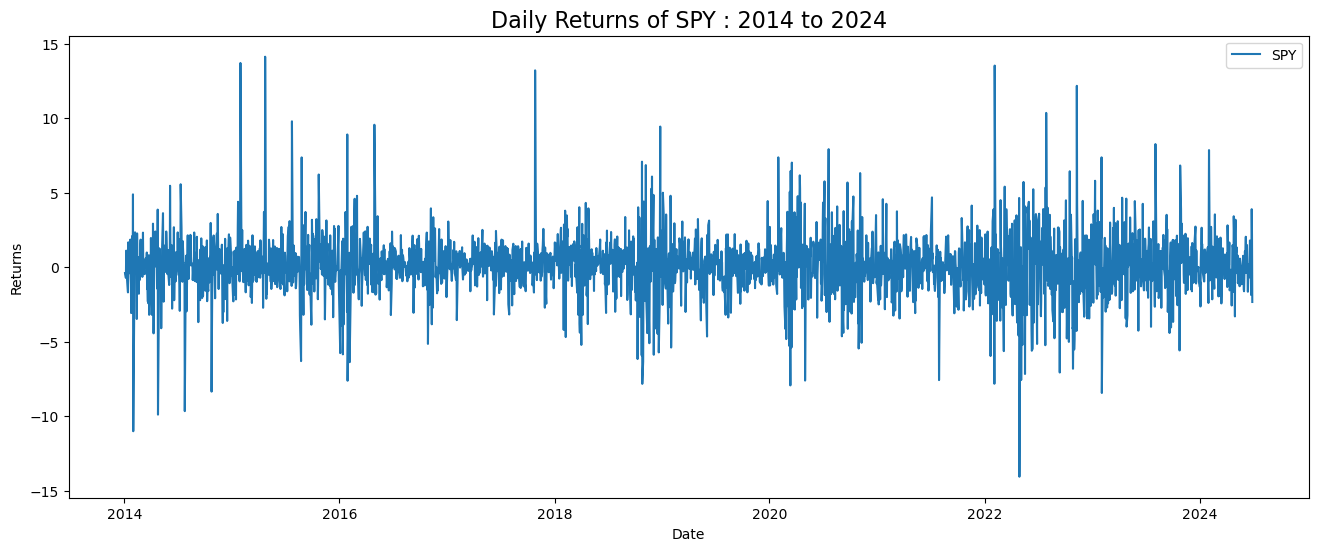

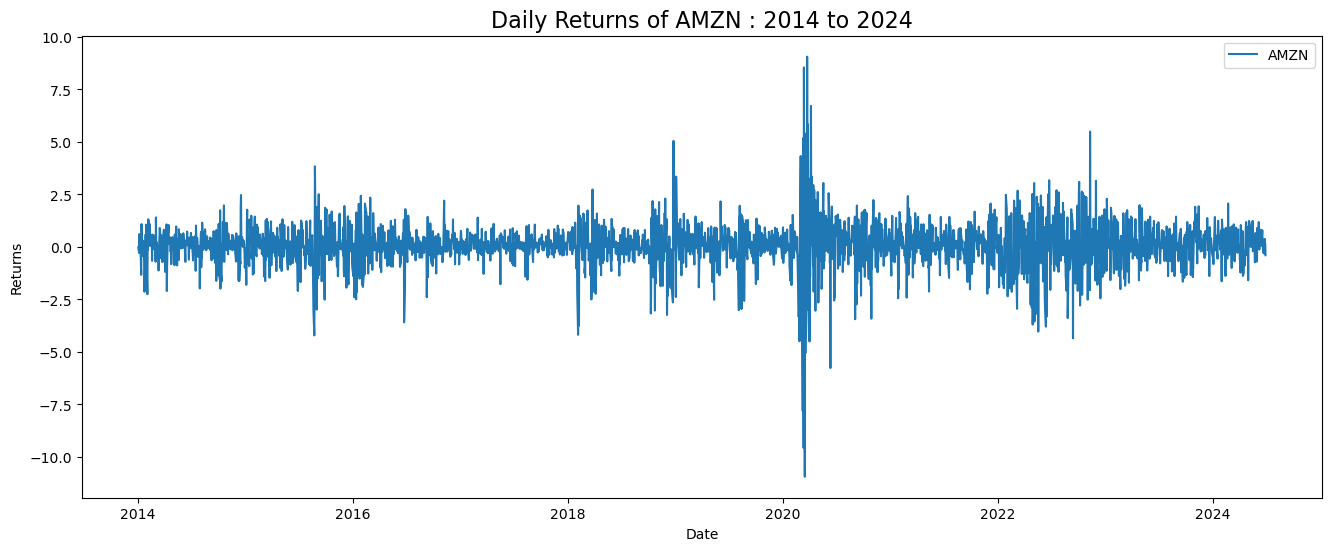

In [111]:
# Plot returns data
for ticker in tickers:
    plt.figure(figsize=(16, 6))

    sns.lineplot(data=returns[ticker], label=ticker)

    title = f"Daily Returns of {ticker}"
    plt.title(f"{title} : {start[:4]} to {end[:4]}", fontsize=16)
    plt.xlabel("Date")
    plt.ylabel("Returns")
    plt.legend()

    # save plot
    # plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

    plt.show()

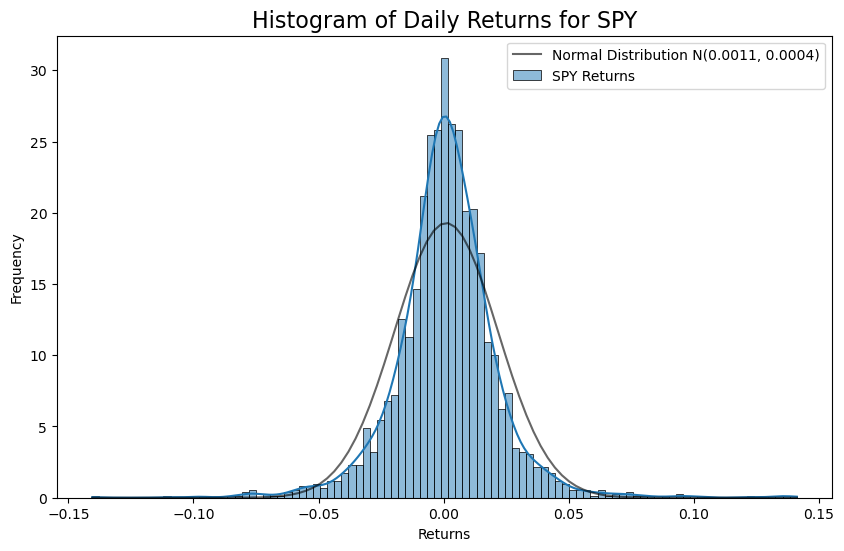

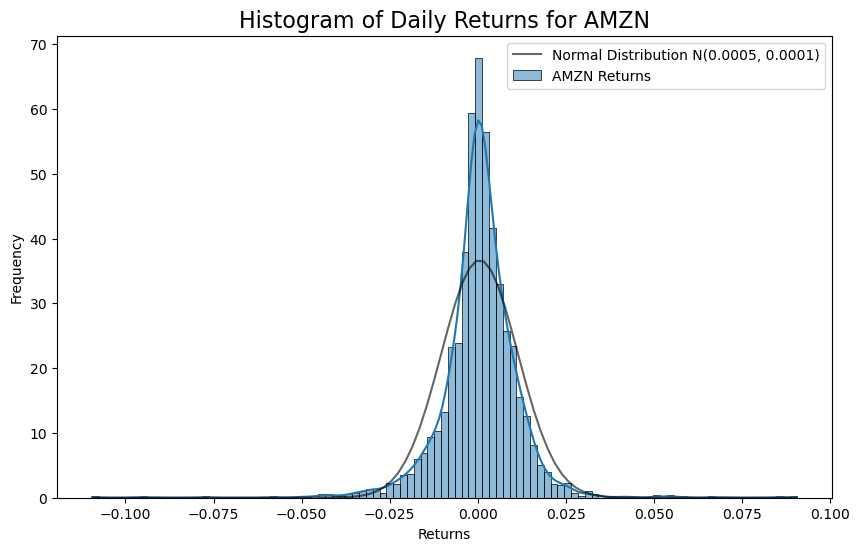

In [49]:
# Plot histogram of returns
for ticker in tickers:
    plt.figure(figsize=(10, 6))

    # Empirical distribution of returns
    sns.histplot(data=returns[ticker], 
        bins='auto', 
        kde=True,
        stat='density', 
        label=f'{ticker} Returns')

    # Theoretical normal distribution curve
    mean = returns[ticker].mean()
    std = returns[ticker].std()
    x = np.linspace(returns[ticker].min(), returns[ticker].max(), 100)
    pdf = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)
    plt.plot(x, pdf, 
        alpha=0.6, 
        color='black', 
        label='Normal Distribution N({:.4f}, {:.4f})'.format(mean, std**2))

    title = f"Histogram of Daily Returns for {ticker}"
    plt.title(title, fontsize=16)
    plt.xlabel("Returns")
    plt.ylabel("Frequency")
    plt.legend()

    # save plot
    plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

    plt.show()

<Figure size 1000x600 with 0 Axes>

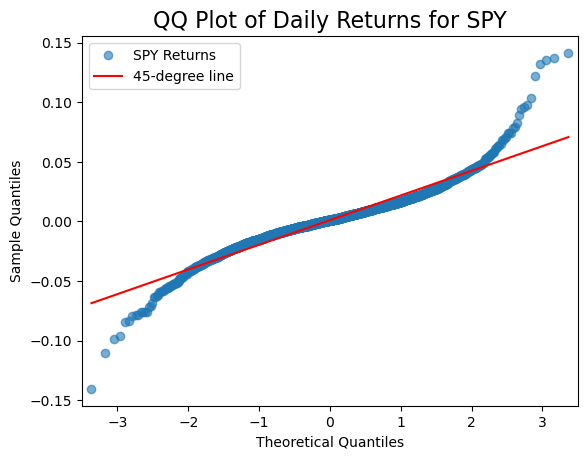

<Figure size 1000x600 with 0 Axes>

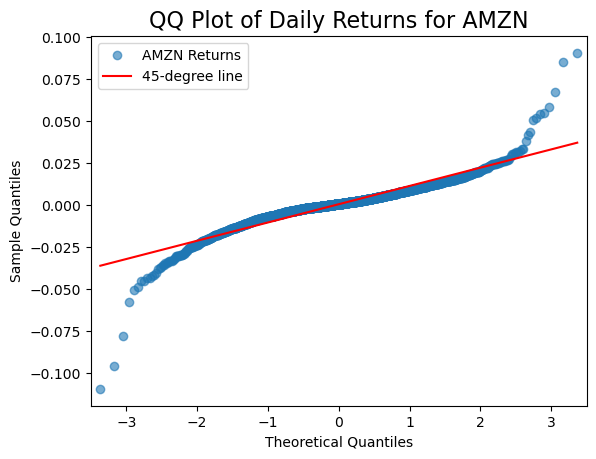

In [56]:
# QQ plots for ticker in tickers
for ticker in tickers:
    plt.figure(figsize=(10, 6))

    # QQ plot
    sm.qqplot(returns[ticker], line='s', alpha=0.6, color='blue')

    title = f"QQ Plot of Daily Returns for {ticker}"
    plt.title(title, fontsize=16)
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.legend([f'{ticker} Returns', '45-degree line'])

    # save plot
    plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

    plt.show()

In [52]:
# descriptive statistics
desc_stats = returns.describe()

skewness = returns.skew()
kurtosis = returns.kurtosis()

# add to descriptive statistics
desc_stats.loc["skew"] = skewness
desc_stats.loc["kurt"] = kurtosis
 
desc_stats

,SPY,AMZN
count,2639.000000,2639.000000
mean,0.001075,0.000544
std,0.020683,0.010876
min,-0.140494,-0.109424
25%,-0.008666,-0.003673
50%,0.001078,0.000615
75%,0.011187,0.005757
max,0.141311,0.090603
skew,0.264319,-0.555189
kurt,6.422159,13.251621


In [57]:
# Normality Analysis

# Jarque-Bera test for normality
# H0: Returns are normally distributed
# If JB is Large or p-value is small => reject null hypthesis of normality

normality_df = pd.DataFrame(index=["Skewness", "Kurtosis", "JB Statistic", "p-value", "H0 Rejection"], columns=tickers)

for ticker in tickers:
    skewness = returns[ticker].skew()
    kurtosis = returns[ticker].kurtosis()
    jb_stat, p_value = jarque_bera(returns[ticker])
    reject_null = p_value < 0.05

    normality_df[ticker] = [skewness, kurtosis, jb_stat, p_value, reject_null]

# save normality results to csv
# normality_df.to_csv("../results/normality_results.csv")

print("Normality Results: ")
normality_df

Normality Results: 


,SPY,AMZN
Skewness,0.264319,-0.555189
Kurtosis,6.422159,13.251621
JB Statistic,4545.46611,19365.031106
p-value,0.0,0.0
H0 Rejection,True,True


In [95]:
# Auto Correlation Analysis

# confidence level for autocorrelation significance
conf_level = 0.95 
t_critical = t.ppf((1 + conf_level) / 2, df=len(returns) - 2) 
acf_conf_interval = t_critical / np.sqrt(len(returns)) # confidence interval for autocorrelation
print(f"Autocorrelation significance threshold (95% confidence): ±{acf_conf_interval:.4f}")

# ACF and PACF values for ticker in tickers 
max_lags = 30
for ticker in tickers:
    acf_values = acf(returns[ticker], nlags=max_lags)
    pacf_values = pacf(returns[ticker], nlags=max_lags) 
    corr_df = pd.DataFrame({ 
        "ACF": acf_values,
        "PACF": pacf_values,
        "t-significance": [abs(val) > acf_conf_interval for val in acf_values],
    }) 

    print(f"Autocorrelation values for {ticker}:")
    print(corr_df)

Autocorrelation significance threshold (95% confidence): ±0.0382
Autocorrelation values for SPY:
         ACF      PACF  t-significance
0   1.000000  1.000000            True
1  -0.014431 -0.014436           False
2  -0.007196 -0.007411           False
3  -0.030860 -0.031115           False
4   0.003818  0.002865           False
5   0.007408  0.007063           False
6  -0.007372 -0.008096           False
7  -0.002946 -0.002867           False
8  -0.050698 -0.050685            True
9   0.037675  0.035876           False
10 -0.022790 -0.022931           False
11 -0.006552 -0.009645           False
12 -0.018298 -0.016473           False
13  0.029014  0.027702           False
14 -0.008420 -0.009714           False
15 -0.035610 -0.036321           False
16  0.019282  0.017775           False
17  0.006793  0.009756           False
18  0.030062  0.024485           False
19 -0.004787 -0.001625           False
20 -0.013673 -0.014203           False
21 -0.030173 -0.026423           False
22 -0.

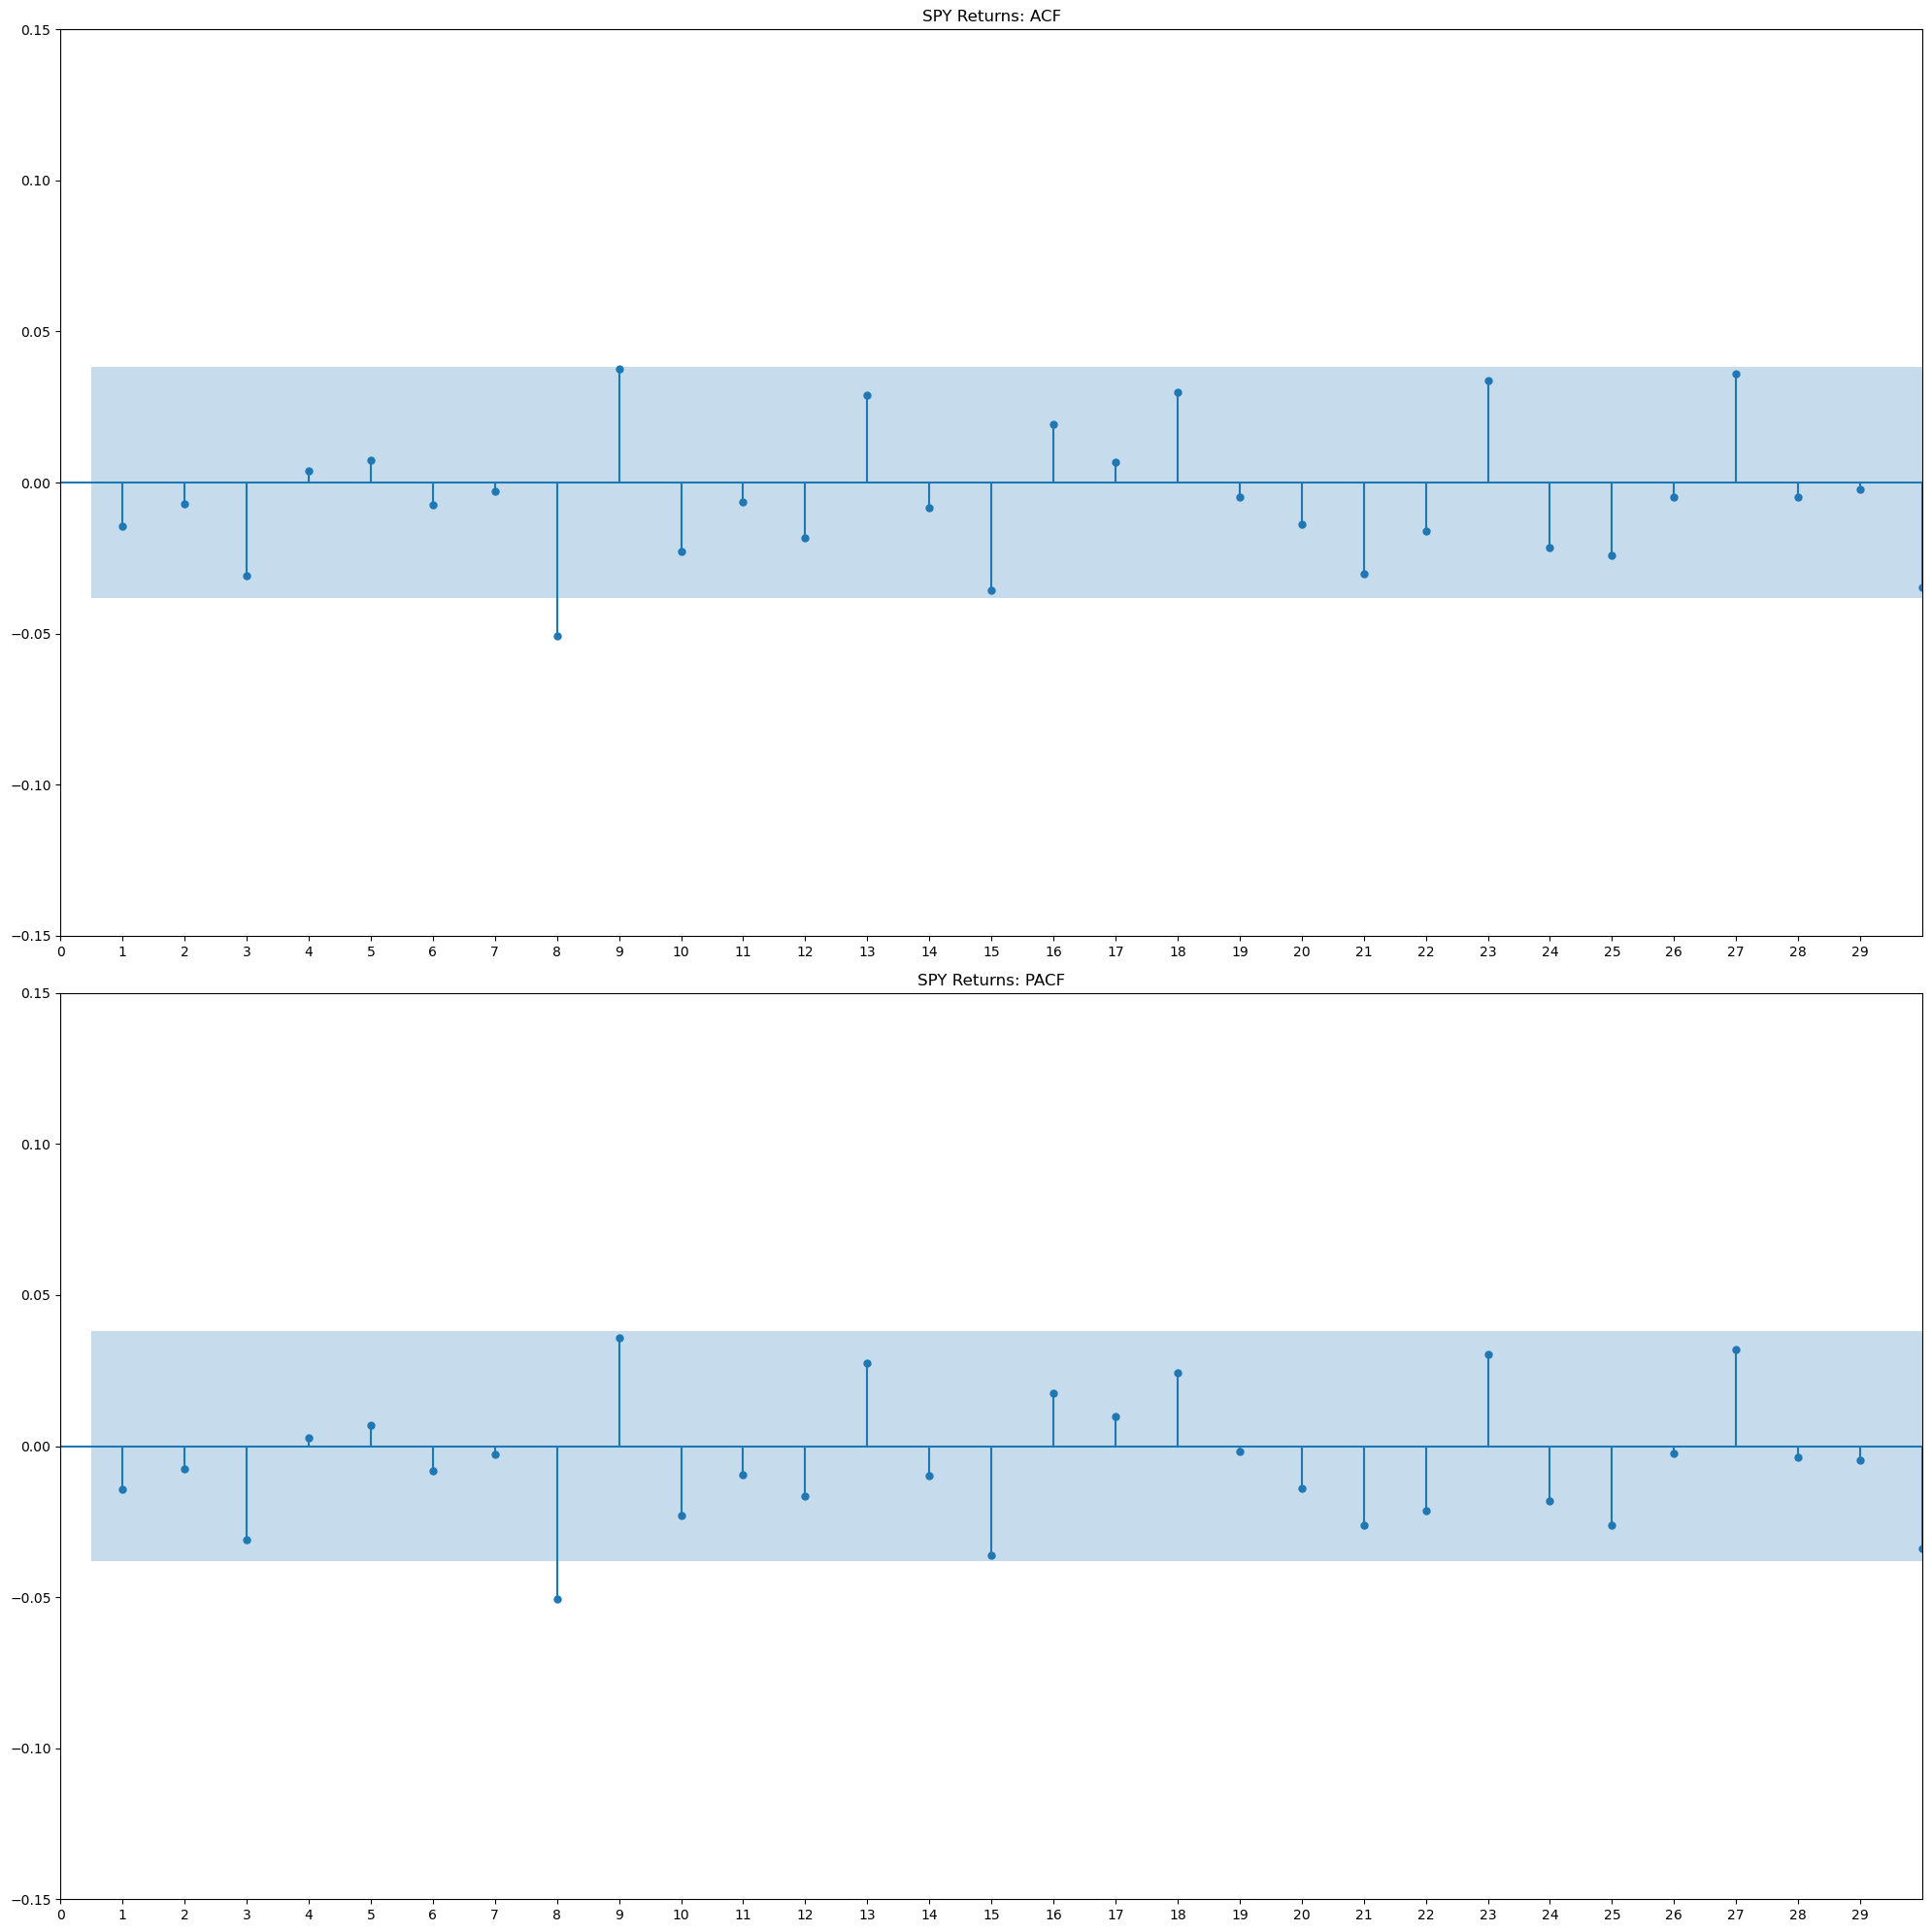

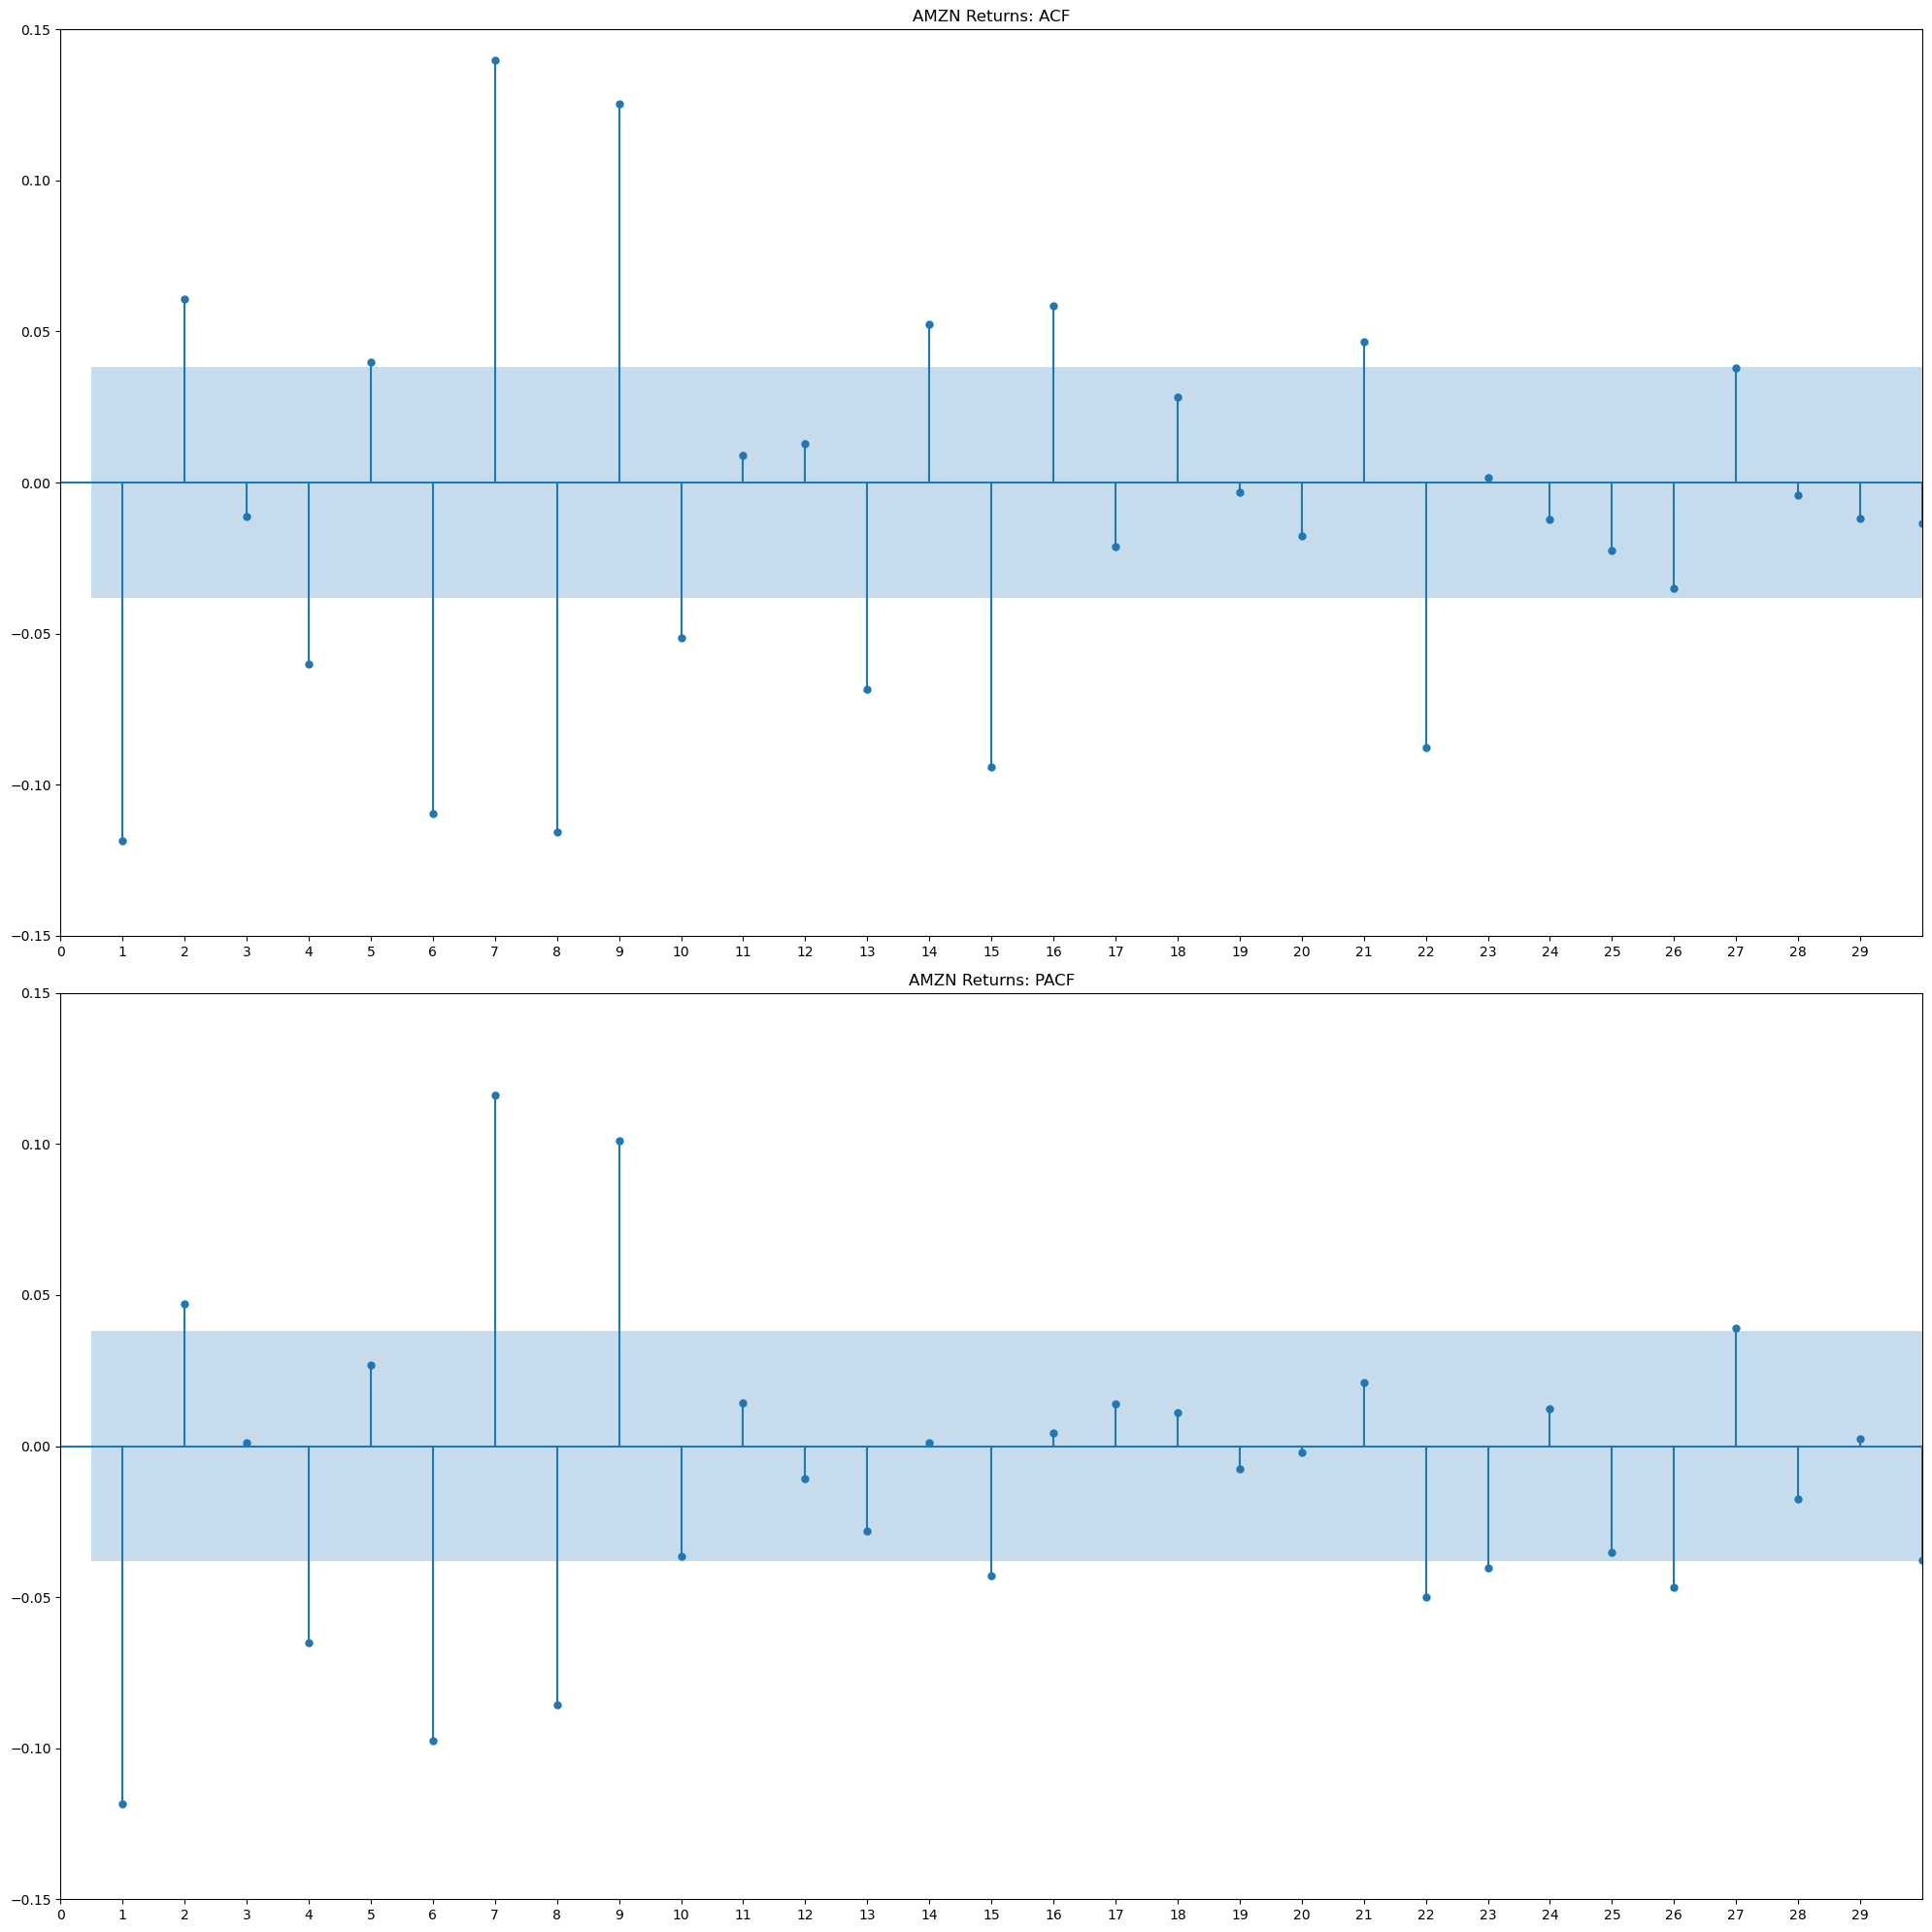

In [99]:
# Plot ACF and PACF for ticker in tickers
for ticker in tickers:
    fig, ax = plt.subplots(2, 1, figsize=(20,20))
    ymin, ymax = -0.15, 0.15

    title = f"{ticker} Returns"
    plot_acf(returns[ticker],
            lags=max_lags,
            bartlett_confint=False,
            ax=ax[0])
    ax[0].set_title(f"{title}: ACF")
    ax[0].set_xlim([0, max_lags])
    ax[0].set_ylim([ymin, ymax])
    ax[0].set_xticks(np.arange(0, max_lags, 1))

    plot_pacf(returns[ticker],
                lags=max_lags,
                method='ywmle',
                alpha=0.05,
                use_vlines=True,
                ax=ax[1])
    ax[1].set_title(f"{title}: PACF")
    ax[1].set_xlim([0, max_lags])
    ax[1].set_ylim([ymin, ymax])
    ax[1].set_xticks(np.arange(0, max_lags, 1)) 

    # save plot
    plt.savefig(f"../results/figures/ACF_PACF_{ticker}.png", dpi=300, bbox_inches="tight")
 
    plt.tight_layout() 
    plt.show()

In [103]:
# Ljung box test for autocorrelation
# H0: No autocorrelation up to lag k
# If p-value is small => reject null hypothesis of no autocorrelation
for ticker in tickers:
    lb_df = acorr_ljungbox(returns[ticker], lags=max_lags, return_df=True)
    lb_df['H0 Rejection'] = lb_df['lb_pvalue'] < 0.05

    lb_df.index.name = "Lag"

    print(f"Ljung-Box test results for {ticker}:")
    print(lb_df.head(10))

Ljung-Box test results for SPY:
       lb_stat  lb_pvalue  H0 Rejection
Lag                                    
1     0.550185   0.458242         False
2     0.687036   0.709271         False
3     3.205000   0.361085         False
4     3.243547   0.517926         False
5     3.388768   0.640281         False
6     3.532635   0.739623         False
7     3.555615   0.829300         False
8    10.364387   0.240376         False
9    14.125928   0.117916         False
10   15.502890   0.114775         False
Ljung-Box test results for AMZN:
        lb_stat     lb_pvalue  H0 Rejection
Lag                                        
1     37.141606  1.098546e-09          True
2     46.854117  6.695111e-11          True
3     47.186651  3.171948e-10          True
4     56.758665  1.390127e-11          True
5     60.964949  7.678196e-12          True
6     92.810921  7.891956e-18          True
7    144.632001  5.434165e-28          True
8    180.147212  9.587699e-35          True
9    221.893094